In [1]:
!git clone https://github.com/jackie-niu/CS9647-Project.git

Cloning into 'CS9647-Project'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 140 (delta 19), reused 29 (delta 11), pack-reused 100 (from 1)
Receiving objects: 100% (140/140), 64.82 MiB | 14.11 MiB/s, done.
Resolving deltas: 100% (48/48), done.


In [2]:
%cd CS9647-Project/

/content/CS9647-Project


In [3]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 76.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 13.5 MB/s eta 0:00:00
  Created wheel for tinysegmenter: filename=tinysegmenter-0.3-py3-none-any.whl size=13540 sha256=012555b6d1b2f5913e92623927af27d83f36cd50351d55bfd4ced0e9af4f7beb
  Stored in directory: /root/.cache/pip/wheels/a5/91/9f/00d66475960891a64867914273fcaf78df6cb04d905b104a2a
  Created wheel for feedfinder2: filename=feedfinder2-0.0.4-py3-none-any.whl size=3341 sha256=b257cf2dfbe911d8db626cea740026f15a8a72cc896787ad8fda3bb2b542b779
  Stored 

In [4]:
!python train.py --root_dir /content/CS9647-Project --run_baselines --epochs 10

GPU available: True
[data] Built and cached dataset: /content/drive/MyDrive/pheme_cache/pheme_clean.csv (rows=97410)
[data] label counts: {0: 67952, 1: 29458}
[split] train=68187 val=14611 test=14612
[split] train label counts: {0: 47566, 1: 20621}

[baseline] TF-IDF + Logistic Regression
               precision    recall  f1-score   support

           0     0.9069    0.8673    0.8866     10193
           1     0.7218    0.7945    0.7564      4419

    accuracy                         0.8453     14612
   macro avg     0.8143    0.8309    0.8215     14612
weighted avg     0.8509    0.8453    0.8472     14612

[baseline] LR metrics: {'accuracy': 0.8452641664385436, 'precision': 0.7218338815789473, 'recall': 0.7945236478841367, 'f1': 0.756436496822148}

[baseline] TF-IDF + Linear SVM
               precision    recall  f1-score   support

           0     0.9124    0.8838    0.8979     10193
           1     0.7501    0.8043    0.7762      4419

    accuracy                         0.85

In [20]:
import pandas as pd

results = pd.DataFrame([
    {"Model": "Logistic Regression (TF-IDF)", "Accuracy": 0.8453, "Precision": 0.7218, "Recall": 0.7945, "F1_misinformation": 0.7564},
    {"Model": "Linear SVM (TF-IDF)", "Accuracy": 0.8598, "Precision": 0.7501, "Recall": 0.8043, "F1_misinformation": 0.7762},
    {"Model": "DistilBERT", "Accuracy": 0.8962, "Precision": 0.8362, "Recall": 0.8169, "F1_misinformation": 0.8264},
])

results.to_csv("/content/drive/MyDrive/pheme_cache/model_results.csv", index=False)

results

,Model,Accuracy,Precision,Recall,F1_misinformation
0,Logistic Regression (TF-IDF),0.8453,0.7218,0.7945,0.7564
1,Linear SVM (TF-IDF),0.8598,0.7501,0.8043,0.7762
2,DistilBERT,0.8962,0.8362,0.8169,0.8264


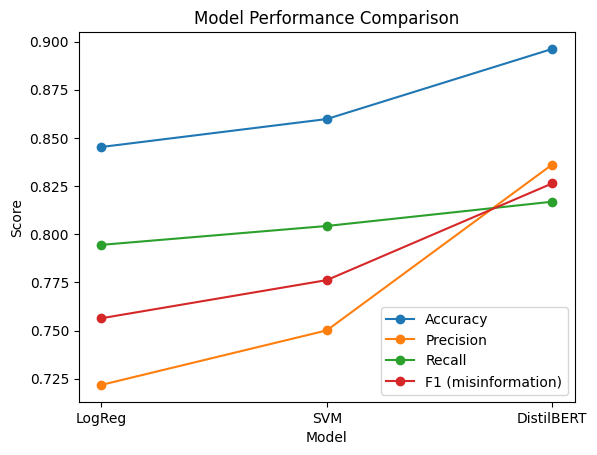

In [21]:
import matplotlib.pyplot as plt

models = ["LogReg", "SVM", "DistilBERT"]
accuracy = [0.8453, 0.8598, 0.8962]
precision = [0.7218, 0.7501, 0.8362]
recall = [0.7945, 0.8043, 0.8169]
f1 = [0.7564, 0.7762, 0.8264]

plt.figure()

plt.plot(models, accuracy, marker='o', label="Accuracy")
plt.plot(models, precision, marker='o', label="Precision")
plt.plot(models, recall, marker='o', label="Recall")
plt.plot(models, f1, marker='o', label="F1 (misinformation)")

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()

plt.savefig("/content/drive/MyDrive/pheme_cache/model_comparison.png")
plt.show()

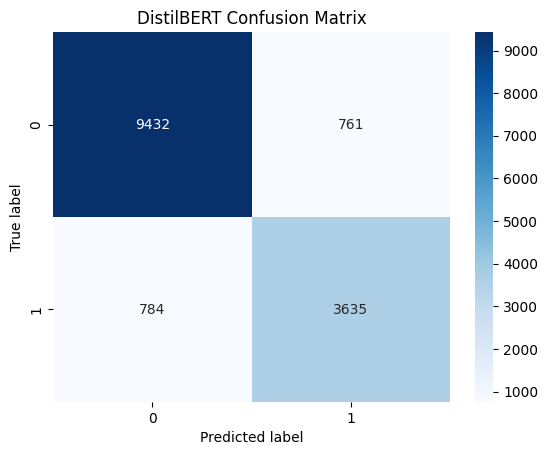

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

cm = np.array([[9432, 761],
               [784, 3635]])

plt.figure()

sns.heatmap(cm, cmap="Blues", annot=True, fmt="d",
            xticklabels=["0", "1"],
            yticklabels=["0", "1"])

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("DistilBERT Confusion Matrix")

plt.savefig("/content/drive/MyDrive/pheme_cache/confusion_matrix.png")

plt.show()

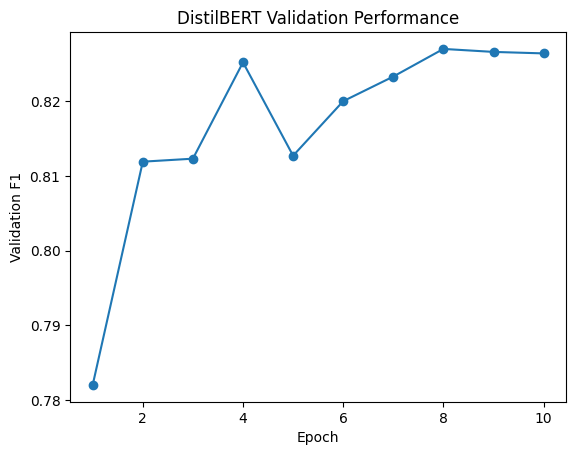

In [23]:
epochs = [1,2,3,4,5,6,7,8,9,10]
val_f1 = [0.782,0.8119,0.8123,0.8252,0.8127,0.8200,0.8233,0.827,0.8266,0.8264]

plt.figure()

plt.plot(epochs, val_f1, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Validation F1")
plt.title("DistilBERT Validation Performance")

plt.savefig("/content/drive/MyDrive/pheme_cache/training_curve.png")

plt.show()

In [24]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/pheme_cache/pheme_clean.csv")

stats = {
    "total_samples": len(df),
    "misinformation": (df["is_misinformation"] == 1).sum(),
    "non_misinformation": (df["is_misinformation"] == 0).sum(),
}

print(stats)

{'total_samples': 97410, 'misinformation': np.int64(29458), 'non_misinformation': np.int64(67952)}


In [25]:
df["length"] = df["text"].apply(lambda x: len(str(x).split()))

df["length"].describe()

,length
count,97410.000000
mean,14.001263
std,6.541750
min,1.000000
25%,9.000000
50%,15.000000
75%,19.000000
max,34.000000


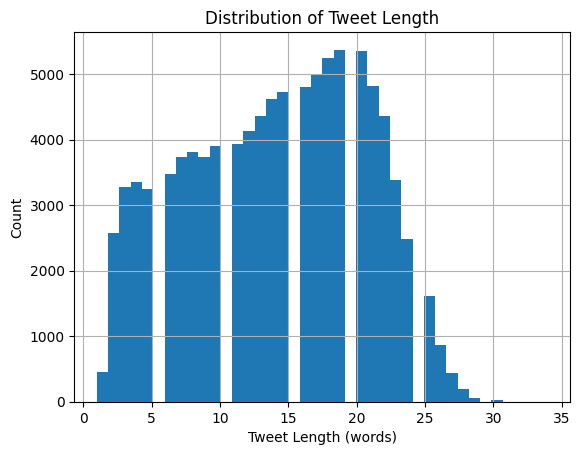

In [26]:
plt.figure()

df["length"].hist(bins=40)

plt.xlabel("Tweet Length (words)")
plt.ylabel("Count")
plt.title("Distribution of Tweet Length")

plt.savefig("/content/drive/MyDrive/pheme_cache/tweet_length_distribution.png")

plt.show()

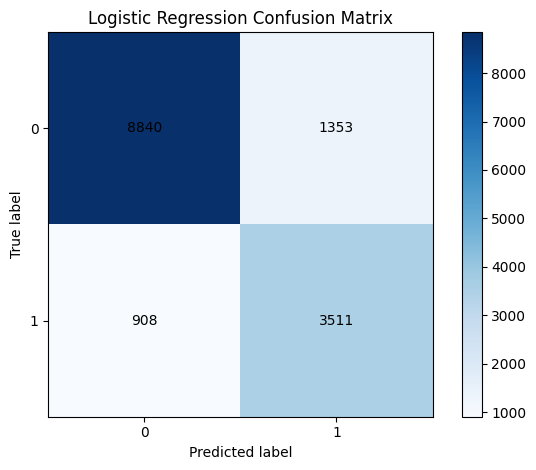

In [28]:
import numpy as np
import matplotlib.pyplot as plt

cm_lr = np.load("/content/drive/MyDrive/pheme_cache/baseline_outputs/lr_confusion_matrix.npy")

plt.figure()
plt.imshow(cm_lr, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/pheme_cache/lr_confusion_matrix.png")
plt.show()

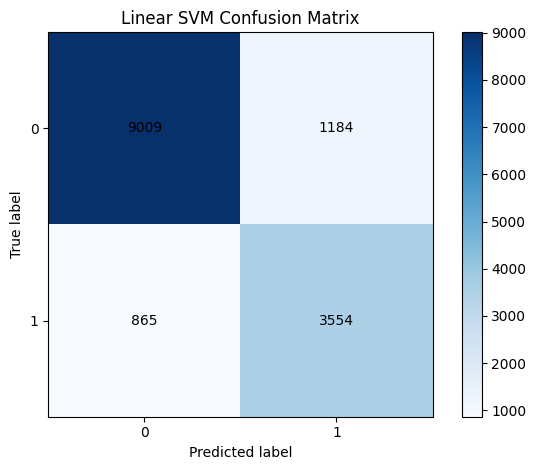

In [29]:
cm_svm = np.load("/content/drive/MyDrive/pheme_cache/baseline_outputs/svm_confusion_matrix.npy")

plt.figure()
plt.imshow(cm_svm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Linear SVM Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])

for i in range(cm_svm.shape[0]):
    for j in range(cm_svm.shape[1]):
        plt.text(j, i, cm_svm[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/pheme_cache/svm_confusion_matrix.png")
plt.show()

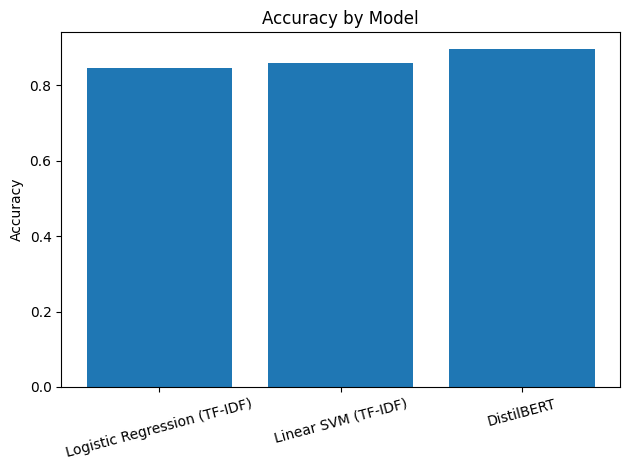

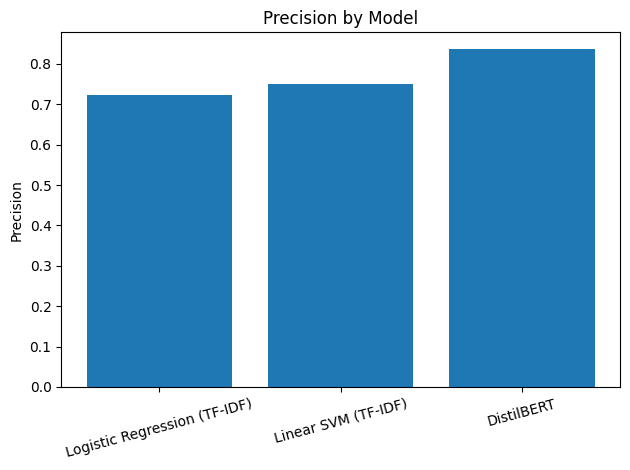

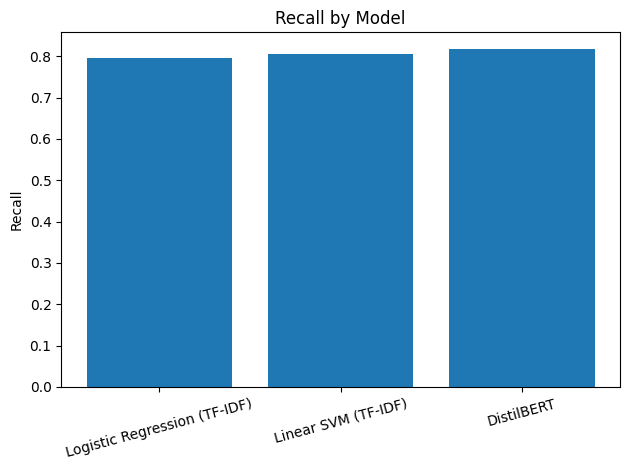

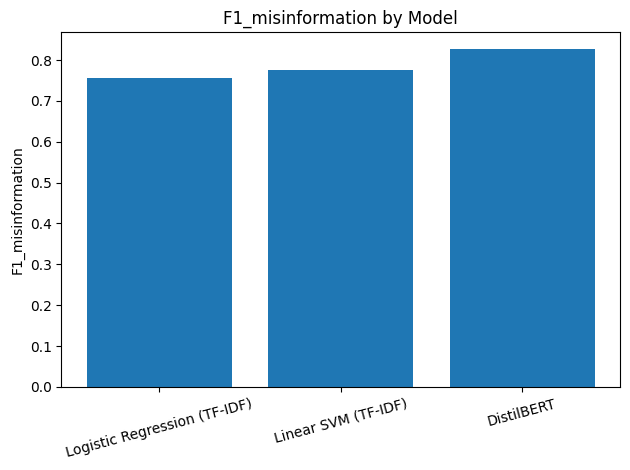

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/pheme_cache/model_results.csv")

metrics = ["Accuracy", "Precision", "Recall", "F1_misinformation"]

for metric in metrics:
    plt.figure()
    plt.bar(df["Model"], df[metric])
    plt.title(f"{metric} by Model")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/pheme_cache/{metric.lower()}_barplot.png")
    plt.show()

In [ ]:
!zip -r /content/outputs.zip /content/drive/MyDrive/pheme_cache

  adding: content/drive/MyDrive/pheme_cache/ (stored 0%)
  adding: content/drive/MyDrive/pheme_cache/training_curve.png (deflated 9%)
  adding: content/drive/MyDrive/pheme_cache/model_comparison.png (deflated 7%)
  adding: content/drive/MyDrive/pheme_cache/confusion_matrix.png (deflated 14%)
  adding: content/drive/MyDrive/pheme_cache/baseline_outputs/ (stored 0%)
  adding: content/drive/MyDrive/pheme_cache/baseline_outputs/lr_report.txt (deflated 54%)
  adding: content/drive/MyDrive/pheme_cache/baseline_outputs/svm_confusion_matrix.npy (deflated 46%)
  adding: content/drive/MyDrive/pheme_cache/baseline_outputs/lr_confusion_matrix.npy (deflated 46%)
  adding: content/drive/MyDrive/pheme_cache/baseline_outputs/svm_report.txt (deflated 54%)
  adding: content/drive/MyDrive/pheme_cache/pheme_clean.csv (deflated 81%)
  adding: content/drive/MyDrive/pheme_cache/runs/ (stored 0%)
  adding: content/drive/MyDrive/pheme_cache/runs/distilbert-base-uncased_pheme/ (stored 0%)
  adding: content/driv